In [22]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "rohanbhuin"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
#else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW4"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/rohanbhuin/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4/STAT-7220-Applied-Experimental-Design
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4/STAT-7220-Applied-Experimental-Design/Assignments/HW4


# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete's biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

**Answer:** The objective of this experiment is to determine whether the two carbon-fiber blade designs, **Model A (Aerostep)** and **Model B (Bionic-Flex)**, produce meaningfully different average 100-meter sprint times among professional T64 sprinters.

Because sprint performance can vary naturally from athlete to athlete due to biomechanics, muscle composition, and training level, the experiment also controls for individual athlete variability. Therefore, the main goal is to compare the mean sprint times between the two blade types while accounting for the fact that each athlete may have their own baseline sprint ability.

2.  Specify the outcome variable and how it is measured.

**Answer:** The **outcome variable** is **Sprint Time**, measures the time, in seconds, that each T64 sprinter takes to complete a 100-meter sprint trial.
This variable is quantitative and continuous.

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

**Answer:** The **independent variable** in this experiment is **Blade Type**.
It is a  categorical variable with two levels: **Aerostep**, and **Bionic-Flex**.
This is a fixed effect because the experiment is specifically interested in comparing these two blade designs.

The **random effect** in this experiment is **Athlete ID**.
It is treated as a random effect because the 5 professional T64 sprinters can be viewed as a sample from a larger population of T64 athletes.

The **Trial** variable represents repeated trials for each athlete under each blade type and provides replication in the experiment.

Possible lurking variables may include:

- Athlete fatigue across repeated trials
- Warm-up differences
- Track or surface conditions
- Weather or indoor/outdoor conditions
- Prosthetic fit or adjustment differences
- Order of blade testing

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

**Answer:** A **fixed effect** is used when the specific levels in the experiment are the main focus of the study. In this experiment, **Blade type** is a fixed effect because we specifically want to compare the two blade designs: **Aerostep** and **Bionic-Flex**.

A **random effect** is used when the levels are treated as a sample from a larger population. Here, **Athlete ID** is a random effect because the athletes represent possible T64 sprinters, and we are not mainly interested in comparing the athletes to each other.

We account for random effects because sprint times can naturally vary from athlete to athlete due to differences in biomechanics, training level, and muscle composition. Including  Athlete ID as a random effect helps control for this natural athlete-to-athlete variability, so the comparison between the two blade types is more accurate.

5.  State the sets of null and alternative hypotheses for this experiment.

**Answer:**
**Fixed Effect Hypotheses: Blade Type**

$$
H_0: \mu_{\text{Aerostep}} = \mu_{\text{Bionic-Flex}}
$$
$$
H_A: \mu_{\text{Aerostep}} \ne \mu_{\text{Bionic-Flex}}
$$

**Random Effect Hypotheses: Athlete**

$$
H_0: \sigma^2_{\text{Athlete}} = 0
$$
$$
H_A: \sigma^2_{\text{Athlete}} > 0
$$

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

**Answer:**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Athlete_ID   30 non-null     object 
 1   Blade_Type   30 non-null     object 
 2   Trial        30 non-null     int64  
 3   Sprint_Time  30 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB
None
    Blade_Type    mean       std  count
0     Aerostep  11.260  0.199428     15
1  Bionic-Flex  11.412  0.193693     15


/tmp/ipykernel_30307/780613667.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


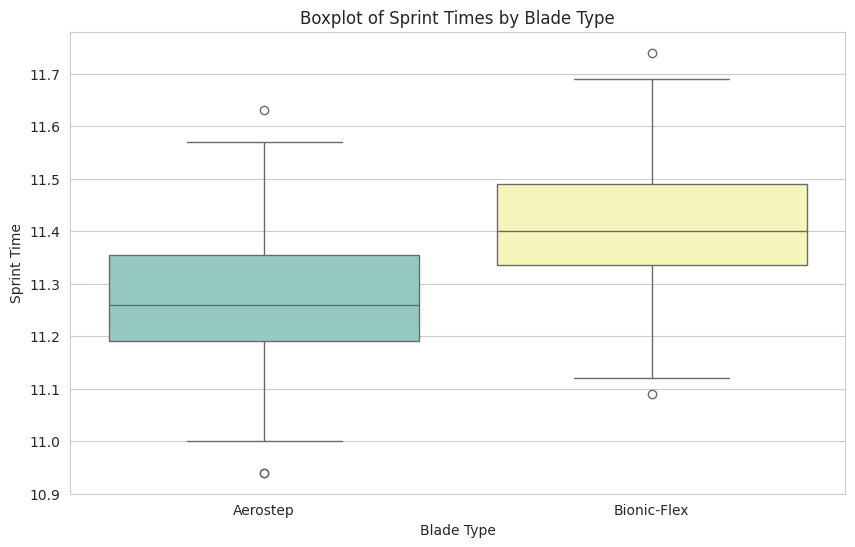

In [23]:
## Question 6 Code ##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import Data ##
blade_data = pd.read_excel("STAT Paralympic_Blade_Experiment.xlsx")

## Evaluate Data Integrity ##
print(blade_data.info())

## Calculate Means and SDs by Blade Type ##
blade_stats = blade_data.groupby('Blade_Type')['Sprint_Time'].agg(['mean', 'std', 'count']).reset_index()

print(blade_stats)

## Visualize Data using Boxplots ##
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Blade_Type',
    y='Sprint_Time',
    data=blade_data,
    palette='Set3'
)

plt.title('Boxplot of Sprint Times by Blade Type')
plt.xlabel('Blade Type')
plt.ylabel('Sprint Time')
plt.show()

Based on the summary statistics, **Bionic-Flex** had a higher average sprint time compared to **Aerostep**.

$$
\bar{x}_{\text{Aerostep}} = 11.260
$$

$$
\bar{x}_{\text{Bionic-Flex}} = 11.412
$$

The boxplot also shows that the distribution of sprint times for **Bionic-Flex** is shifted slightly higher than the distribution for **Aerostep**. Since lower sprint time indicates better performance, the descriptive results suggest that athletes were, on average, faster using **Aerostep** than **Bionic-Flex**.

Therefore, the EDA provides visual and descriptive support for the **alternative fixed effect hypothesis** that the mean sprint time differs between the two blade types.

    Blade_Type Athlete_ID       mean       std  count
0     Aerostep  Athlete_1  11.530000  0.124900      3
1     Aerostep  Athlete_2  10.960000  0.034641      3
2     Aerostep  Athlete_3  11.273333  0.032146      3
3     Aerostep  Athlete_4  11.316667  0.066583      3
4     Aerostep  Athlete_5  11.220000  0.065574      3
5  Bionic-Flex  Athlete_1  11.703333  0.032146      3
6  Bionic-Flex  Athlete_2  11.133333  0.051316      3
7  Bionic-Flex  Athlete_3  11.370000  0.043589      3
8  Bionic-Flex  Athlete_4  11.463333  0.068069      3
9  Bionic-Flex  Athlete_5  11.390000  0.036056      3


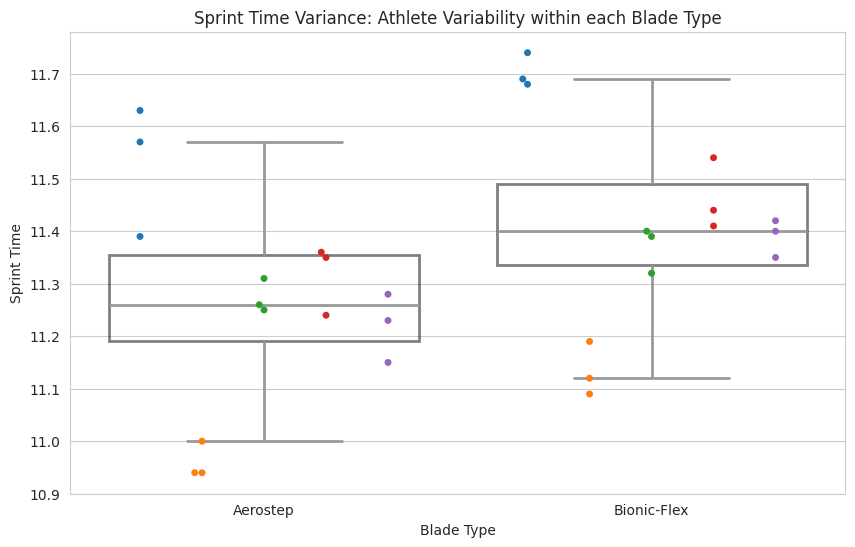

In [24]:
## Athlete within Blade Type ##

athlete_data = blade_data.groupby(['Blade_Type', 'Athlete_ID'])['Sprint_Time'].agg(['mean','std','count']).reset_index()

print(athlete_data)

## Swarm + Boxplot to show Athlete variability within Blade Type ##

plt.figure(figsize=(10, 6))

sns.swarmplot(
    x='Blade_Type',
    y='Sprint_Time',
    hue='Athlete_ID',
    data=blade_data,
    dodge=True,
    palette='tab10',
    legend=False
)

sns.boxplot(
    x='Blade_Type',
    y='Sprint_Time',
    data=blade_data,
    color='white',
    linewidth=2,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black', 'alpha':0.5}
)

plt.title('Sprint Time Variance: Athlete Variability within each Blade Type')
plt.xlabel('Blade Type')
plt.ylabel('Sprint Time')
plt.show()

Based on the summary statistics by Blade Type and Athlete ID, there appears to be noticeable variability in sprint times among athletes within each blade type.

For **Aerostep**, the athlete means range from approximately:

$$
10.960 \text{ to } 11.530
$$

For **Bionic-Flex**, the athlete means range from approximately:

$$
11.133 \text{ to } 11.703
$$

The swarm plot also shows that the sprint times are not clustered at the same level for all athletes. Some athletes consistently have lower sprint times, while others have higher sprint times within each blade type. This suggests that individual athletes may have different baseline sprint performances.

Therefore, the EDA provides visual and descriptive support for the **alternative random effect hypothesis** that athlete-to-athlete variability in sprint time is greater than zero.

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

**Answer:**

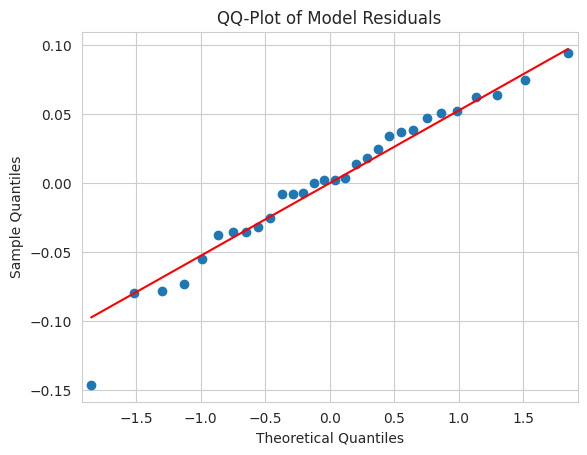

Shapiro-Wilk Test Results:
Statistic: 0.9713
p-value: 0.5746


In [25]:
## Question 7 Code ##

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

## Fit Mixed Effects Model ##
mixed_model = smf.mixedlm(
    formula='Sprint_Time ~ Blade_Type',
    data=blade_data,
    groups=blade_data['Athlete_ID'],
    re_formula='1'
)

mixed_results = mixed_model.fit(method=["powell"], maxiter=5000, reml=False)

## Parse out Model Residuals ##
residuals = mixed_results.resid

## QQ-Plot ##
sm.qqplot(residuals, line='s')
plt.title("QQ-Plot of Model Residuals")
plt.show()

## Shapiro-Wilk Test ##
shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic:.4f}")
print(f"p-value: {shapiro_test.pvalue:.4f}")

Based on the QQ-plot, most of the residuals fall approximately along the reference line, with only a small deviation in the lower tail. This suggests that the residuals appear to be approximately normally distributed.

The Shapiro-Wilk test results were:

$$
W = 0.9713
$$

$$
p = 0.5746
$$

Since the p-value is greater than 0.05, we **fail to reject the null hypothesis of normality**. Therefore, there is not enough evidence to suggest that the residuals significantly deviate from a normal distribution.

Overall, the normality assumption appears to be **reasonably satisfied** for the mixed effects model.


8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

**Answer:**

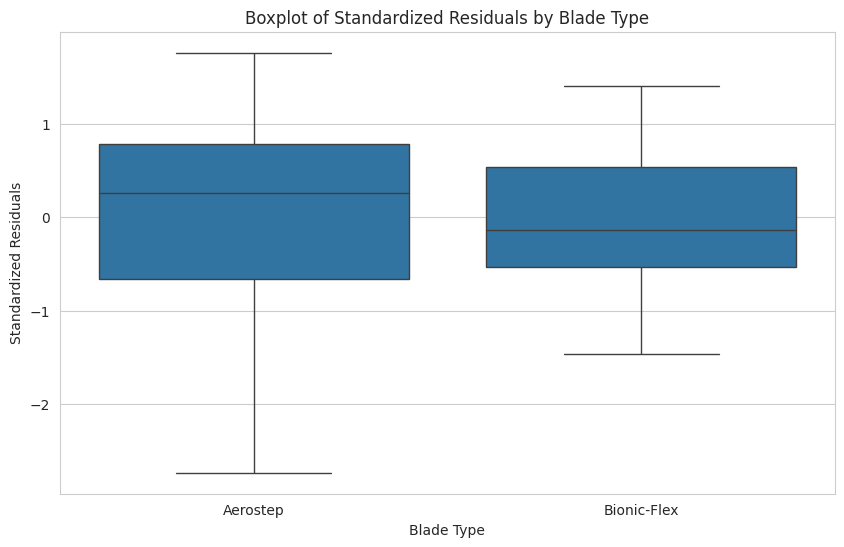

Breusch-Pagan Test Results:
F Statistic: 1.7588
F p-value: 0.1955


In [26]:
## Question 8 Code ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Create Standardized Residuals ##
blade_data['Standardized_Residuals'] = mixed_results.resid / mixed_results.resid.std()

## Boxplot of Standardized Residuals by Blade Type ##
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Blade_Type',
    y='Standardized_Residuals',
    data=blade_data
)

plt.title("Boxplot of Standardized Residuals by Blade Type")
plt.xlabel("Blade Type")
plt.ylabel("Standardized Residuals")
plt.show()

## Breusch-Pagan Test ##
bp_test = het_breuschpagan(mixed_results.resid, mixed_results.model.exog)

print("Breusch-Pagan Test Results:")
print(f"F Statistic: {bp_test[2]:.4f}")
print(f"F p-value: {bp_test[3]:.4f}")

Based on the boxplot, the spread of standardized residuals looks reasonably similar for both **Aerostep** and **Bionic-Flex**. Although Aerostep shows a slightly wider spread, there is no strong visual pattern suggesting serious unequal variance.

As a supporting check, the Breusch-Pagan test results were:

$$
F = 1.7588
$$

$$
p = 0.1955
$$

Since the p-value is greater than 0.05, we **fail to reject the null hypothesis of constant variance**. Therefore, there is not enough statistical evidence to suggest that the residual variance is unequal across the fitted model.

Overall, the constant variance assumption appears to be **reasonably satisfied** for the mixed effects model.


9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

**Answer:**

In [27]:
## Question 9 Code ##

## Fit Reduced Model ##
reduced_model = smf.ols(
    formula='Sprint_Time ~ Blade_Type',
    data=blade_data
)

reduced_results = reduced_model.fit()

## Likelihood Ratio Test for Athlete Random Effect ##
llf_full = mixed_results.llf
llf_reduced = reduced_results.llf

lr_stat = 2 * (llf_full - llf_reduced)
p_value = stats.chi2.sf(lr_stat, df=1)

print(f"Likelihood Ratio Test Statistic: {lr_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Likelihood Ratio Test Statistic: 51.1891
p-value: 0.0000


The likelihood ratio test was used to determine whether including **Athlete ID** as a random effect significantly improved the model.

The test results were:

$$
LR = 51.1891
$$

$$
p < 0.05
$$

Since the p-value is less than 0.05, we **reject the null hypothesis** that the athlete-to-athlete variance is equal to zero.

This provides strong evidence that there is meaningful variability among athletes i.e. the **alternative random effect hypothesis** is more strongly supported by the data. Therefore, including **Athlete ID** as a random effect is appropriate for this experiment.


10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

**Answer:**

In [28]:
## Question 10 Code ##

## Fixed Effect Results ##
print(mixed_results.summary())

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 ML         
No. Groups:           5           Scale:                  0.0033     
Min. group size:      6           Log-Likelihood:         32.8616    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.082 136.820 0.000 11.099 11.421
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.241 0.000  0.111  0.193
Group Var                  0.033    0.401                            



The mixed effects model was used to evaluate whether **Blade Type** had a significant effect on sprint time while accounting for **Athlete ID** as a random effect.

From the model output, the estimated mean sprint time for **Aerostep** was: **11.260**.
The coefficient for **Bionic-Flex** was: **0.152**
with:  $p < 0.05$.

Since the p-value is less than 0.05, we **reject the null hypothesis** that the mean sprint time is the same for both blade types.

Therefore, the **alternative fixed effect hypothesis** is more strongly supported by the data. The results provide strong evidence that **Blade Type has a significant effect on sprint time**.

The positive coefficient indicates that **Bionic-Flex had an estimated average sprint time 0.152 seconds higher than Aerostep**. Since lower sprint time indicates better performance, this suggests that **Aerostep produced faster sprint times on average**.


11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.

**Answer:** Overall, the results provide strong evidence that **Blade Type has a significant effect on 100-meter sprint time**. After accounting for athlete-to-athlete variability using **Athlete ID** as a random effect, **Bionic-Flex had an estimated average sprint time 0.152 seconds higher than Aerostep**. Since lower sprint times indicate better performance, this suggests that athletes performed faster on average using **Aerostep**.

The random effect result also showed strong evidence of meaningful variability among athletes. This supports the use of a mixed effects model because individual athletes naturally differ in sprint performance due to factors such as biomechanics, muscle composition, and training level.

The model assumptions were reasonably satisfied. The residuals appeared approximately normal based on the QQ-plot and Shapiro-Wilk test, and the constant variance assumption was supported by the residual boxplot and Breusch-Pagan test.

One limitation of this experiment is the small sample size, since only 5 athletes participated. Also, the results are based only on 100-meter sprint performance, so they may not fully generalize to other race distances or broader groups of T64 sprinters. Future studies could include more athletes, more trials, and additional performance measures such as comfort, fatigue, and long-term blade adaptation.

In conclusion, the data support **Aerostep** as the better-performing blade design in this experiment.
